In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph, END
from langgraph.types import Command
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.schema import SystemMessage, HumanMessage
from IPython.display import Image, display
from typing import TypedDict

# Initialize the language model
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
# Define the agent's state
class WritingState(TypedDict):
    topic: str
    current_draft: str
    review_feedback: str
    final_paragraph: str
    iteration: int
    review_score: float

In [3]:
def generate_paragraph(state: WritingState):
    print("Generating Initial Draft")
    prompt = f"Write a compelling introductory paragraph for a blog about: {state['topic']}"
    response = llm.invoke([
        SystemMessage(content="You are a professional content writer."),
        HumanMessage(content=prompt)
    ])
    state["current_draft"] = response.content
    state["iteration"] = 1
    state["review_score"] = 0
    return Command(goto="review_paragraph", update=state)

In [4]:
def review_paragraph(state: WritingState):
    print("Reviewing Paragraph")
    prompt = f"""
    Review the following blog introduction for clarity, tone, structure, and engagement:{state['current_draft']}
    Provide feedback and suggest improvements.
    Then give an overall score out of 10 in this format:
    final_score: <number>
    """
    response = llm.invoke([
        SystemMessage(content="You are a senior content editor."),
        HumanMessage(content=prompt)
    ])
    state["review_feedback"] = response.content
    try:
        last_line = response.content.strip().split("\n")[-1]
        state["review_score"] = float(last_line.split(":")[-1].strip())
    except:
        state["review_score"] = 5  # default fallback score
    return Command(goto="refine_paragraph", update=state)

In [6]:
def refine_paragraph(state: WritingState):
    print("Refining Paragraph")
    print("Review Score:", state["review_score"], "Iteration:", state["iteration"])
    # Check stopping condition
    if state["review_score"] >= 9 or state["iteration"] >= 3:
        print(state)
        print("Reflection is completed and the content is ready now.")
        state["final_paragraph"] = state["current_draft"]
        return Command(goto=END, update=state)
    prompt = f"""
    Improve the following paragraph based on the review feedback:
    Paragraph:
    {state['current_draft']}
    Feedback:
    {state['review_feedback']}
    Rewrite it to improve clarity, tone, and structure.
    """
    response = llm.invoke([
        SystemMessage(content="You are a writing assistant."),
        HumanMessage(content=prompt)
    ])
    state["current_draft"] = response.content
    state["iteration"] += 1
    return Command(goto="review_paragraph", update=state)

In [7]:
workflow = StateGraph(WritingState)

workflow.add_node("generate_paragraph", generate_paragraph)
workflow.add_node("review_paragraph", review_paragraph)
workflow.add_node("refine_paragraph", refine_paragraph)

workflow.set_entry_point("generate_paragraph")

graph = workflow.compile()

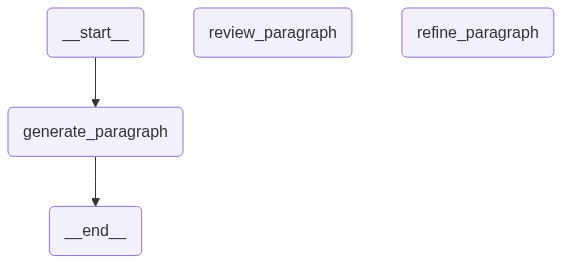

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
input_data = {"topic": "The Impact of Remote Work on Team Productivity"}
result = graph.invoke(input_data)

print("\n=== Final Refined Paragraph ===\n")
print(result["final_paragraph"])
print("\n=== Final Review Feedback ===\n")
print(result["review_feedback"])

Generating Initial Draft
Reviewing Paragraph
Refining Paragraph
Review Score: 9.5 Iteration: 1
{'topic': 'The Impact of Remote Work on Team Productivity', 'current_draft': 'The global shift to remote work, accelerated by unprecedented circumstances, has fundamentally reshaped our professional landscapes. But beneath the surface of newfound flexibility and reduced commutes lies a more complex question, one that every organization is grappling with: What is the true impact of remote work on team productivity? This isn\'t just about whether people are working; it\'s about *how well* they\'re collaborating, innovating, and achieving collective goals in a virtual environment, and the answers are far more nuanced than a simple "yes" or "no."', 'review_feedback': 'This is a very strong blog introduction. It effectively sets the stage, introduces a compelling problem, and clearly articulates the scope and depth of the topic.\n\nHere\'s a breakdown:\n\n**Clarity:** Excellent. The introduction c